In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('CPMI_Data.xlsx')

In [ ]:
# Display the first few rows of the DataFrame
print(df.head())

                                     Statistic Label          Month  \
0  Consumer Price Index (Base Month November 1996...  1996 November   
1  Consumer Price Index (Base Month November 1996...  1996 November   
2  Consumer Price Index (Base Month November 1996...  1996 November   
3  Consumer Price Index (Base Month November 1996...  1996 November   
4  Consumer Price Index (Base Month November 1996...  1996 November   

                                    Commodity Group  \
0                                         All Items   
1                  Food and non-alcoholic beverages   
2        Alcoholic beverages, tobacco and narcotics   
3                             Clothing and footwear   
4  Housing, water, electricity, gas and other fuels   

                             UNIT  VALUE  
0  Base Month November 1996 = 100  100.0  
1  Base Month November 1996 = 100  100.0  
2  Base Month November 1996 = 100  100.0  
3  Base Month November 1996 = 100  100.0  
4  Base Month November 1996

In [ ]:
# Display the summary information about the DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39424 entries, 0 to 39423
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Statistic Label  39424 non-null  object 
 1   Month            39424 non-null  object 
 2   Commodity Group  39424 non-null  object 
 3   UNIT             39424 non-null  object 
 4   VALUE            30324 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.5+ MB
None


In [7]:
# Drop unnecessary columns
df.drop(columns=['Statistic Label', 'UNIT'], inplace=True)

# convert 'Date' column to datetime format
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year

# exclude null from the value column
df = df.dropna(subset=['VALUE'])

KeyError: "['Statistic Label', 'UNIT'] not found in axis"

In [8]:
df.head()

,Month,Commodity Group,VALUE,Year
0,1996-11-01,All Items,100.0,1996
1,1996-11-01,Food and non-alcoholic beverages,100.0,1996
2,1996-11-01,"Alcoholic beverages, tobacco and narcotics",100.0,1996
3,1996-11-01,Clothing and footwear,100.0,1996
4,1996-11-01,"Housing, water, electricity, gas and other fuels",100.0,1996


In [12]:
# To find the trend of the filter of all item
all_item = df[df['Commodity Group'] == 'All Items']

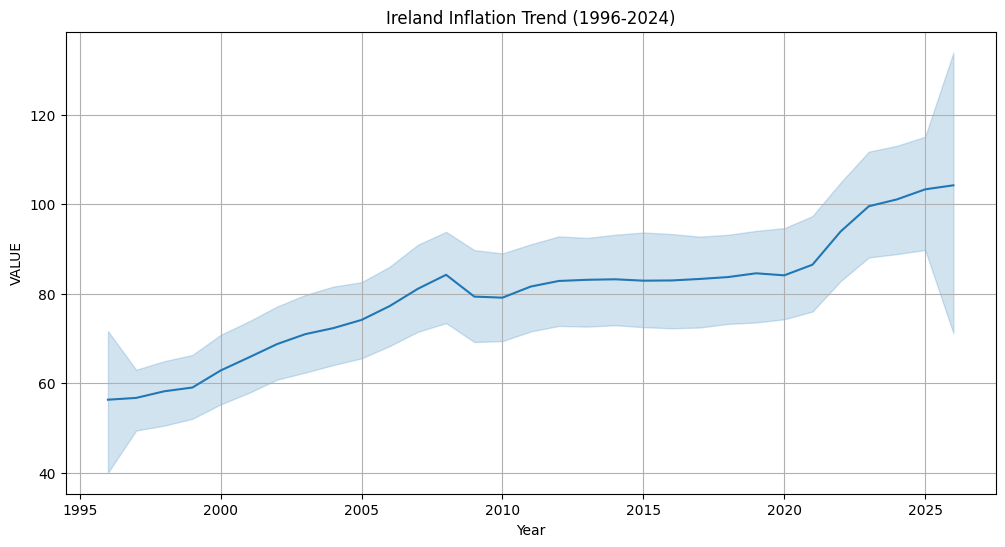

In [14]:
#make the graph of the all item
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_item, x='Year', y='VALUE')
plt.title('Ireland Inflation Trend (1996-2024)')
plt.grid(True)
plt.show()

In [15]:
# To set the data for time series format
# use only the 'Month' and 'VALUE' columns
ts_data = all_item[['Month', 'VALUE']]
ts_data.set_index('Month', inplace=True)

In [16]:
# To check data does it have any missing value to stable the model
ts_data = ts_data.resample('MS').mean().ffill()

print("Data is ready for forecasting.")

Data is ready for forecasting.


In [18]:
ts_data.head()

,VALUE
Month,
1996-11-01,56.3000
1996-12-01,56.3000
1997-01-01,55.9875
1997-02-01,56.4750
1997-03-01,56.3875


In [24]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA model
model = ARIMA(ts_data ['VALUE'], order=(5,1,0))
model_fit = model.fit()

# Forecast the next 12 months
forecast_obj = model_fit.get_forecast(steps=12)
predicted_values = forecast_obj.summary_frame()

print("upcoming 12 month inflation forecast:")
print(predicted_values[['mean', 'mean_ci_lower', 'mean_ci_upper']])


upcoming 12 month inflation forecast:
VALUE             mean  mean_ci_lower  mean_ci_upper
2026-03-01  104.575269     103.628497     105.522041
2026-04-01  104.803097     103.437600     106.168594
2026-05-01  104.596326     102.807893     106.384759
2026-06-01  104.904060     102.726538     107.081583
2026-07-01  104.794705     102.159992     107.429419
2026-08-01  104.889513     101.870520     107.908506
2026-09-01  104.839681     101.442261     108.237101
2026-10-01  104.924684     101.174688     108.674681
2026-11-01  104.884801     100.787938     108.981665
2026-12-01  104.921444     100.505600     109.337289
2027-01-01  104.906051     100.181452     109.630649
2027-02-01  104.930154      99.913390     109.946918


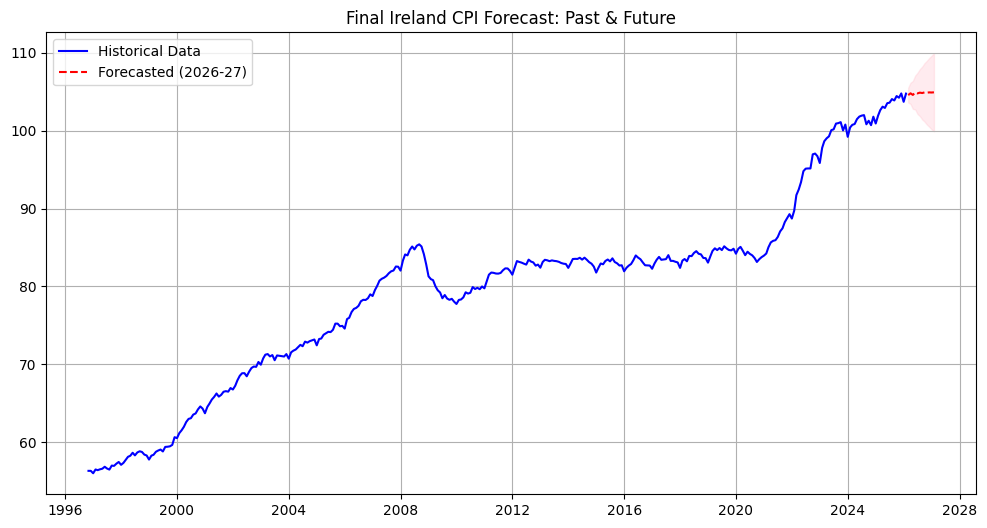

In [ ]:

plt.figure(figsize=(12, 6))

# Past Data (Old Trend)
plt.plot(ts_data.index, ts_data['VALUE'], label='Historical Data', color='blue')

# Predicted Data (Upcoming Trend)
plt.plot(predicted_values.index, predicted_values['mean'], label='Forecasted (2026-27)', color='red', linestyle='--')

# Confidence Interval (To show the range)
plt.fill_between(predicted_values.index,
predicted_values['mean_ci_lower'],
predicted_values['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('Final Ireland CPI Forecast: Past & Future')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# To get the diffrence btween old values and predicted values
actual = ts_data['VALUE'][-12:] # Last 12 month values
pred = model_fit.predict(start=len(ts_data)-12, end=len(ts_data)-1)

# MAPE Calculation (mean error percentage)
mape = np.mean(np.abs((actual - pred) / actual)) * 100
accuracy = 100 - mape

print(f"Model Accuracy: {accuracy:.2f}%")
print(f"Average Error: {mape:.2f}%")

Model Accuracy: 99.63%
Average Error: 0.37%
